#### Versuch exact matching zu evaluieren

In [1]:
import os
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from eval_p1_functions import *

In [2]:
def read_file(file_path):
    with open(file_path, 'r', encoding="utf-8") as file:
        return file.read()

def extract_nct_number(filename):
    match = re.search(r'(NCT\d+)', filename)
    return match.group(1) if match else None

def extract_operators(text):
    operators = re.findall(r'\[(AND|OR|NOT)\]', text)
    return operators

def find_operator_words(text, operators):
    words = {op: [] for op in operators}
    word_list = text.split()
    for i, word in enumerate(word_list):
        if word in ["[AND]", "[OR]", "[NOT]"]:
            operator = word[1:-1]
            if operator in ['AND', 'OR', 'NOT'] and i - 1 >= 0: # Wort vor dem Operator
                prev_word = re.sub(r'[^\w]', '', word_list[i - 1])  # Entferne Satzzeichen
                words[operator].append(prev_word)
    return words

In [3]:

def compare_operators(label_text, model_text, operator):
    label_operators = extract_operators(label_text)
    model_operators = extract_operators(model_text)

    label_words_dict = find_operator_words(label_text, label_operators)
    model_words_dict = find_operator_words(model_text, model_operators)

    
    
    label_words = label_words_dict.get(operator, [])
    model_words = model_words_dict.get(operator, [])
    print("label_words_dict",label_words)
    print("model_words_dict",model_words)
    print([word for word in label_words if word in model_words])
    
    tp = sum(1 for word in label_words if word in model_words)
    fp = sum(1 for word in model_words if word not in label_words)
    fn = sum(1 for word in label_words if word not in model_words)

    return tp, fp, fn, len(label_words), len(model_words)

def calculate_metrics(tp, fp, fn):
    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0
    accuracy = tp / (tp + fn) if tp + fn > 0 else 0
    return precision, recall, f1, accuracy

def clean_criteria_text(edited_text):
    # Remove logical operators and tags
    cleaned_text = re.sub(r'\[AND\]|\[OR\]|\[NOT\]', '', edited_text)
    cleaned_text = re.sub(r'<EDITED_CRITERIA>|</EDITED_CRITERIA>', '', cleaned_text)
    # Strip leading and trailing whitespaces
    cleaned_text = cleaned_text.strip()
    return cleaned_text

def compare_texts(raw_text, model_text):
    # Normalize and tokenize text for comparison
    raw_text_words = raw_text.split()
    model_text_words = model_text.split()

    raw_word_count = Counter(raw_text_words)
    model_word_count = Counter(model_text_words)

    # Calculate missing words and their counts
    missing_words = raw_word_count - model_word_count

    total_words = sum(raw_word_count.values())
    missing_word_count = sum(missing_words.values())
    missing_percentage = (missing_word_count / total_words) * 100

    return missing_words, missing_percentage

In [4]:
def evaluate_models(label_folder, model_folder,model_name, output_folder="excel_eval"):
    operators = ['AND', 'OR', 'NOT']
    metrics = {op: {'tp': 0, 'fp': 0, 'fn': 0, 'label_count': 0, 'model_count': 0, 'correct_count': 0, 'correct_ncts': set(), 'low_tp_ncts': set()} for op in operators}
    processed_label_files = 0
    total_missing_words = Counter()
    total_missing_pct = 0.0
    model_results = []
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for model_file in os.listdir(model_folder):
        if model_file.endswith('.txt'):
            nct_number = extract_nct_number(model_file)
            if nct_number:
                print(nct_number)
                label_file_path = os.path.join(label_folder, f'{nct_number}.txt')
                model_file_path = os.path.join(model_folder, model_file)
                raw_lct_text_path = os.path.join(raw_lct_text_folder, f'{nct_number}.txt')

                if os.path.exists(label_file_path):
                    processed_label_files += 1
                    label_text = read_file(label_file_path)
                    model_text = read_file(model_file_path)

                    raw_lct_text = read_file(raw_lct_text_path)
                    model_raw_text = clean_criteria_text(model_text)
                    missing_words, missing_percentage = compare_texts(raw_lct_text, model_raw_text)
                    total_missing_pct += missing_percentage
                    total_missing_words.update(missing_words)
                    
                    # Ausgabe der Ergebnisse
                    #print("Missing Words:", missing_words)
                    #print("Missing Percentage: {:.2f}%".format(missing_percentage))
                    
                    model_data = {'nct_number': nct_number}

                    for op in operators:
                        tp, fp, fn, label_count, model_count = compare_operators(label_text, model_text, op)

                        metrics[op]['tp'] += tp
                        metrics[op]['fp'] += fp
                        metrics[op]['fn'] += fn
                        metrics[op]['label_count'] += label_count
                        metrics[op]['model_count'] += model_count
                        metrics[op]['correct_count'] += tp

                        model_data[f'{op}_tp'] = tp
                        model_data[f'{op}_fp'] = fp
                        model_data[f'{op}_fn'] = fn
                        model_data[f'{op}_label_count'] = label_count
                        model_data[f'{op}_model_count'] = model_count

                        if tp > 0:
                            metrics[op]['correct_ncts'].add(nct_number)
                        if tp == 0 and fn > 4:
                            metrics[op]['low_tp_ncts'].add(nct_number)

                    model_results.append(model_data)

    results = {}
    for op in operators:
        precision, recall, f1, accuracy = calculate_metrics(metrics[op]['tp'], metrics[op]['fp'], metrics[op]['fn'])
        results[op] = {
            'precision': precision * 100,
            'recall': recall * 100,
            'f1': f1 * 100,
            'accuracy': accuracy * 100,
            'total_label': metrics[op]['label_count'],
            'total_model': metrics[op]['model_count'],
            'correct_count': metrics[op]['correct_count'],
            'low_tp_ncts': list(metrics[op]['low_tp_ncts'])  # Konvertiere das Set zurück in eine Liste für die Ausgabe
        }

    # Durchschnittliche fehlende Wörter pro Modell berechnen
    average_missing_percentage = total_missing_pct / processed_label_files if processed_label_files > 0 else 0
    results['average_missing_percentage'] = average_missing_percentage

    # Berechne die durchschnittliche Performance über alle Operatoren
    avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0, 'accuracy': 0}
    for metric in avg_metrics.keys():
        avg_metrics[metric] = sum(results[op][metric] for op in operators) / len(operators)
    
    results['average'] = avg_metrics

    # Evaluierungsergebnisse in eine Excel-Datei schreiben
    df_results = pd.DataFrame(model_results)
    excel_path = os.path.join(output_folder, f'{model_name}_evaluation_results.xlsx')
    #with pd.ExcelWriter(excel_path) as writer:
    #    df_results.to_excel(writer, sheet_name='Model Results', index=False)

    return results


### Wähle den evaluations Ordner

In [6]:
versuch_ordner = "eval_p1/" #"versuche/versuch_2_p1/0_shot" #eval_p1_n_shot/" # "eval_p1/"

label_folder = '../input/lct_p1'
raw_lct_text_folder = '../input/lct_txt'
model_output_folder = versuch_ordner + 'model_output'

models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]

In [7]:
all_metrics = {}

for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder, model)

    all_metrics[model] = metrics
    print(all_metrics)
    
    # Berechne die durchschnittliche Performance über alle Operatoren
    # avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0, 'accuracy': 0}
    # for metric in avg_metrics.keys():
    #     print(metric)
    #     avg_metrics[metric] = sum(metrics[op][metric] for op in metrics) / len(metrics)
    # 
    # # Attach the average scores to the model's metrics
    # metrics['average'] = avg_metrics
    # all_metrics[model] = metrics
    

NCT03860012
label_words_dict []
model_words_dict ['treatment']
[]
label_words_dict ['21']
model_words_dict ['21']
['21']
label_words_dict []
model_words_dict []
[]
NCT03860025
label_words_dict []
model_words_dict ['patients', 'controls']
[]
label_words_dict []
model_words_dict ['one']
[]
label_words_dict ['THA']
model_words_dict ['THA']
['THA']
NCT03860038
label_words_dict []
model_words_dict []
[]
label_words_dict ['male', 'transplant', 'weeks']
model_words_dict ['18', 'male', 'phase', 'transplant', 'OR', 'OR', 'response', 'weeks', 'treatment', 'longer']
['male', 'transplant', 'weeks']
label_words_dict []
model_words_dict ['of', 'is']
[]
NCT03860064
label_words_dict ['18', 'uterus']
model_words_dict ['18', 'uterus']
['18', 'uterus']
label_words_dict ['chemotherapy']
model_words_dict ['kg', 'chemotherapy']
['chemotherapy']
label_words_dict []
model_words_dict []
[]
NCT03860090
label_words_dict []
model_words_dict ['Patients']
[]
label_words_dict ['pacemaker']
model_words_dict ['pacemak

### Missing Words PCT

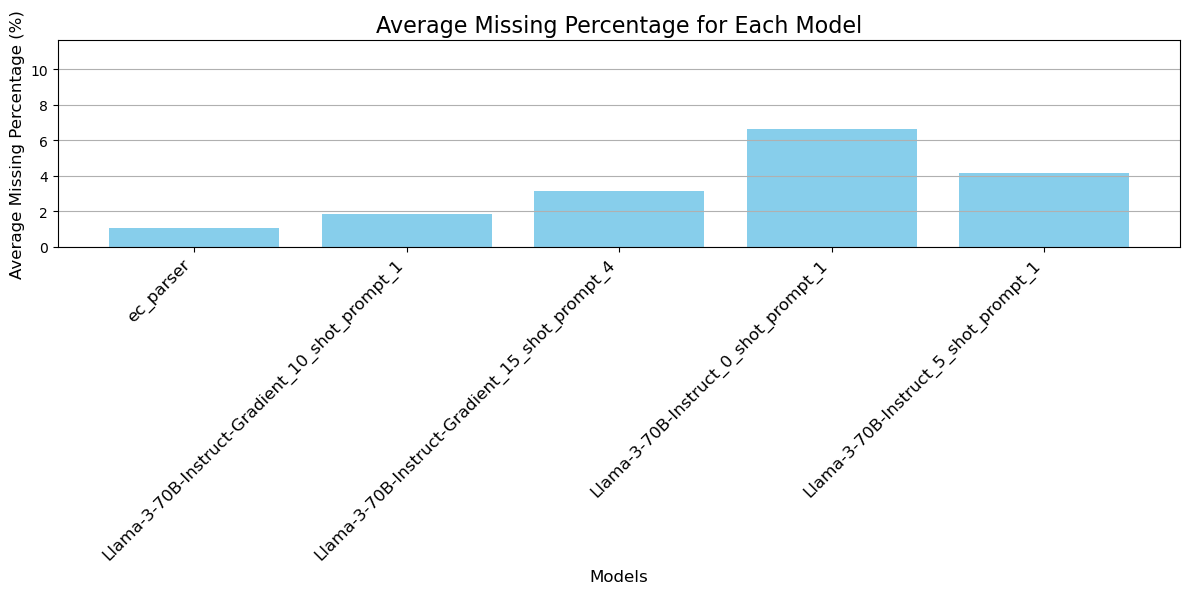

In [8]:
def plot_avg_missing_pct(all_metrics):
    model_names = []
    avg_missing_pcts = []

    for model, metrics in all_metrics.items():
        model_names.append(model)
        avg_missing_pcts.append(metrics['average_missing_percentage'])

    x = range(len(model_names))

    plt.figure(figsize=(12, 6))
    plt.bar(x, avg_missing_pcts, color='skyblue')
    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Average Missing Percentage (%)', fontsize=12)
    plt.title('Average Missing Percentage for Each Model', fontsize=16)
    plt.xticks(x, model_names, rotation=45, ha='right', fontsize=12)
    plt.ylim(0, max(avg_missing_pcts) + 5)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
plot_avg_missing_pct(all_metrics)

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] 

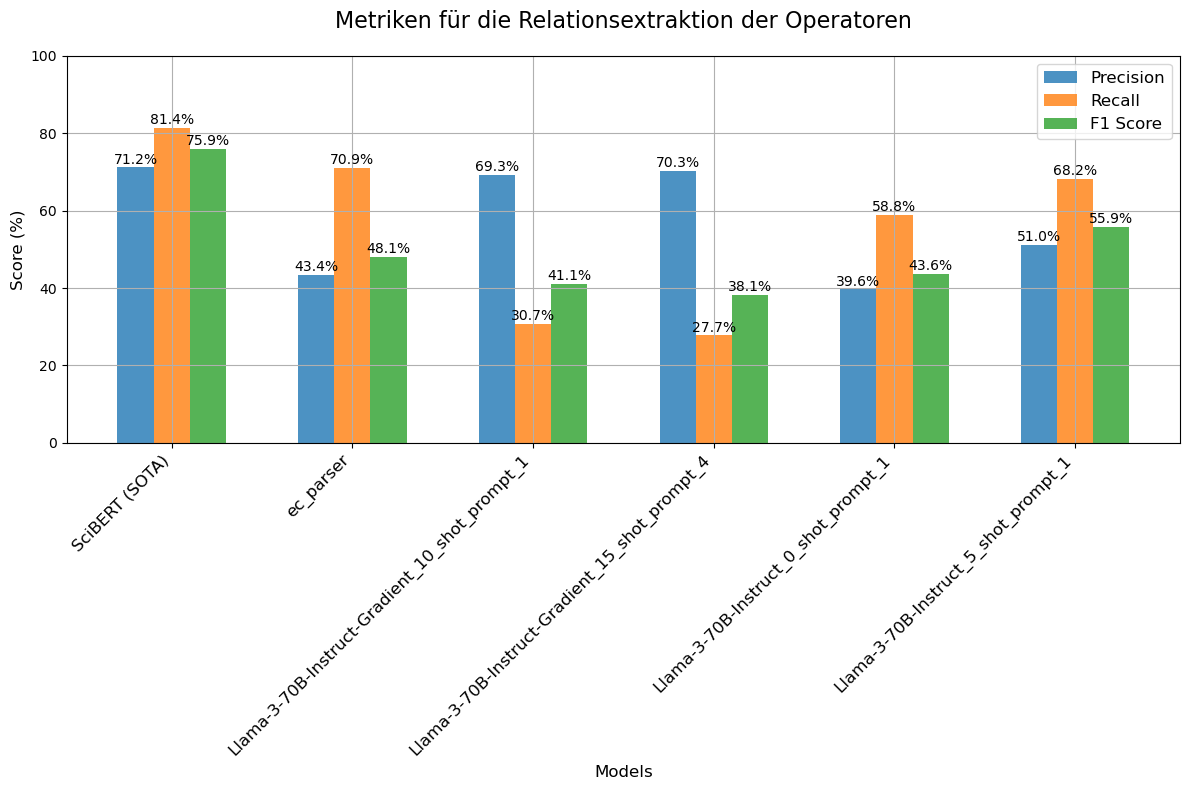

In [9]:
plot_avg_metrics(all_metrics)

### Perfomance der einzelnen Operatoren

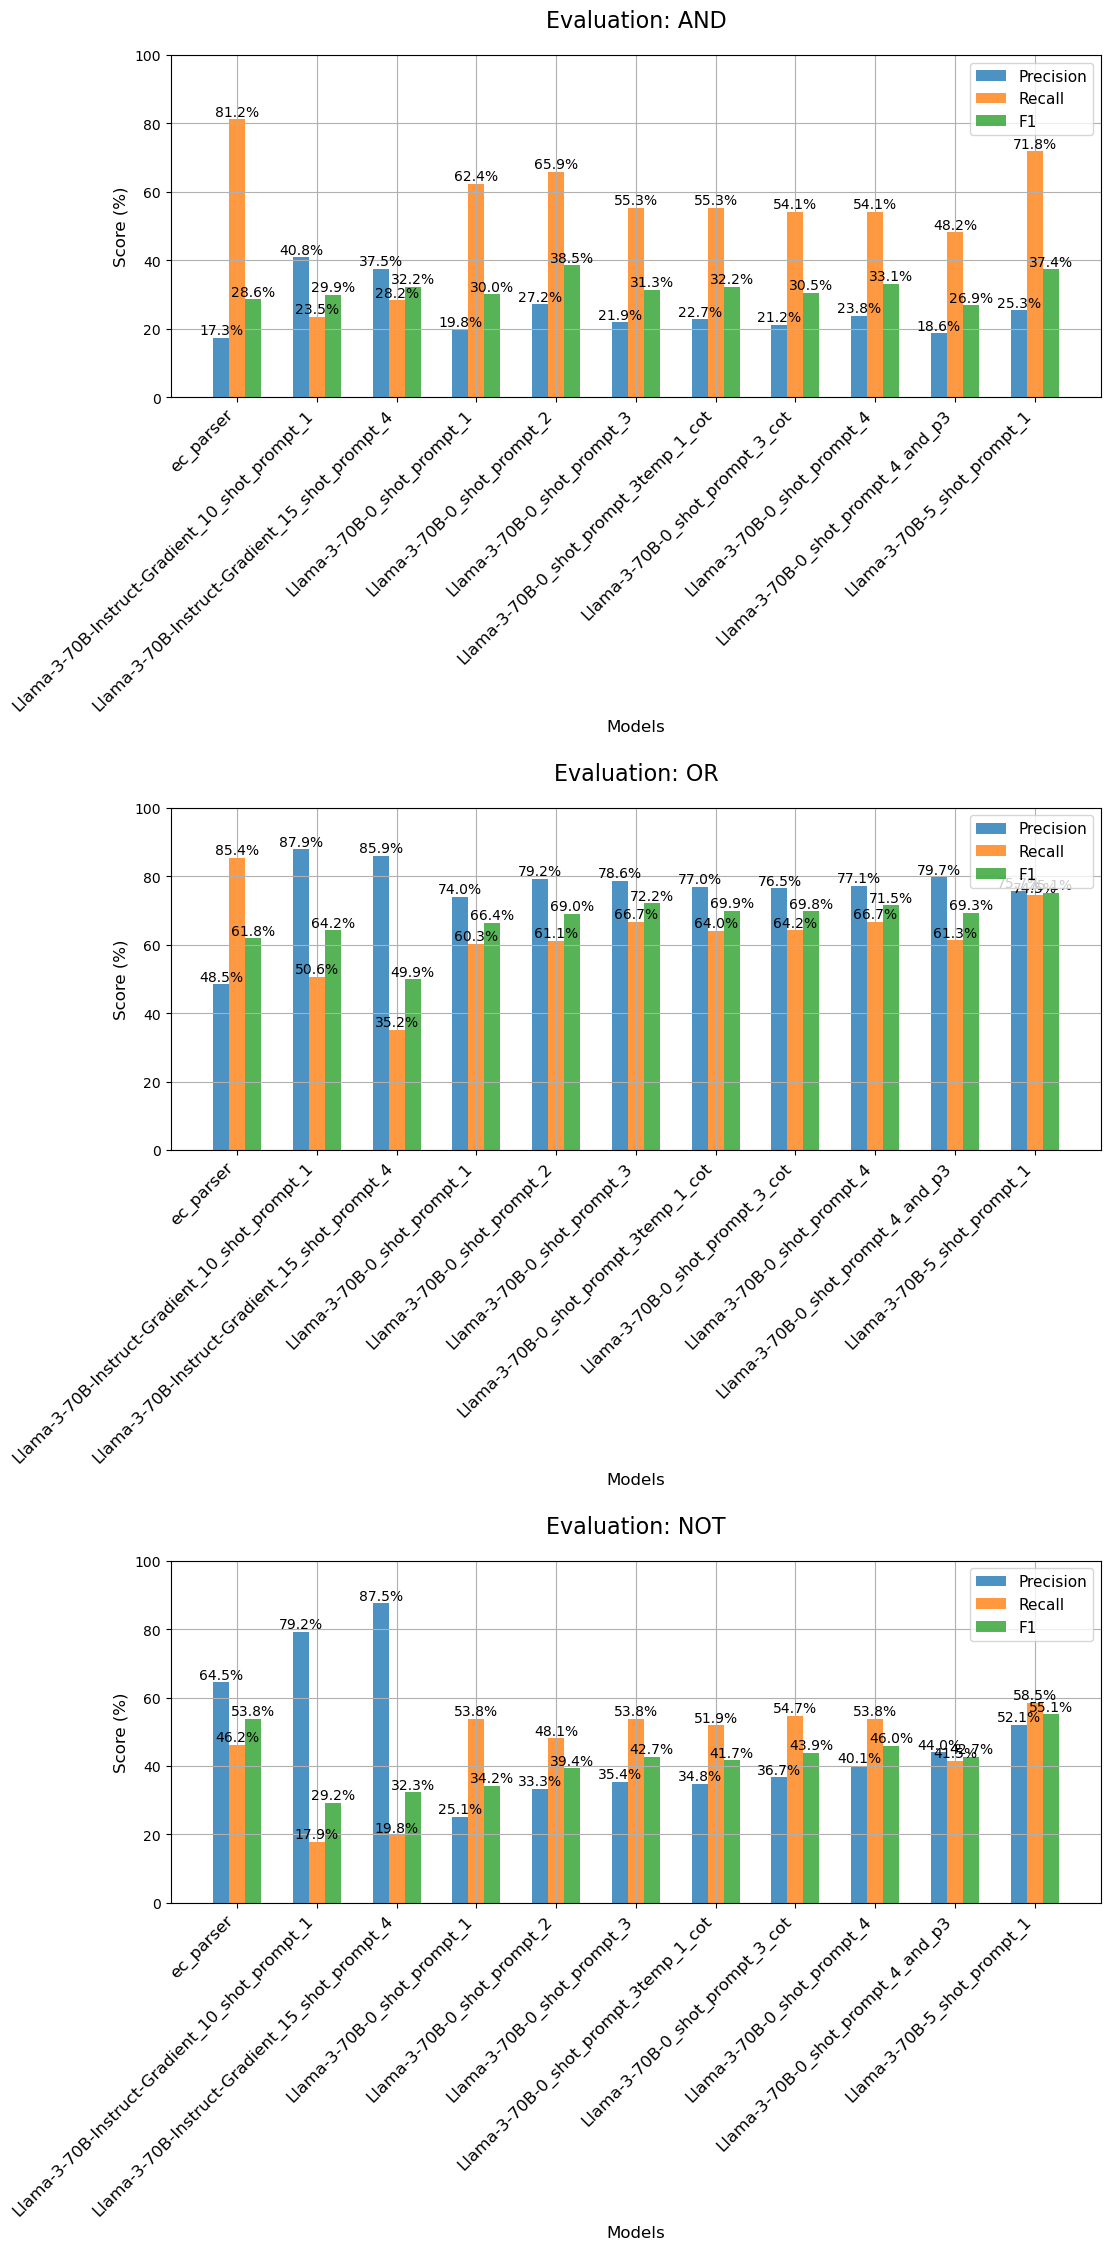

In [9]:
# 1 Instruct
# 2 Instruct +  5 Beispiele
# 3 
# 7 
# 9 
# 10 
plot_metrics(all_metrics)

### Plot Anzahl Operators

In [10]:
def plot_count_comparison(all_metrics):
    operators = ['AND', 'OR', 'NOT']
    count_metrics = ['total_label', 'total_model']
    fig, ax = plt.subplots(figsize=(16, 8))
    x = np.arange(len(operators))

    label_counts = [all_metrics[next(iter(all_metrics))][op]['total_label'] for op in operators]
    bar_width = 0.16
    opacity = 0.8

    colors = sns.color_palette("husl", len(all_metrics) + 1)

    ax.bar(x, label_counts, bar_width, alpha=opacity, color=colors[0], label='Label Count')
    for i, model in enumerate(all_metrics.keys()):
        count_values = [all_metrics[model][op]['total_model'] for op in operators]
        model_name = model.replace('Instruct', '').replace('_', ' ')
        ax.bar(x + (i + 1) * bar_width, count_values, bar_width, alpha=opacity, color=colors[i + 1], label=model_name)

        for j, v in enumerate(count_values):
            label_count = label_counts[j]
            diff_percent = ((v - label_count) / label_count) * 100
            color = 'darkgreen' if diff_percent >= 0 else 'red'
            ax.text(x[j] + (i + 1) * bar_width, v / 2, f'{diff_percent:+.0f}%', ha='center', va='center', fontsize=10, color=color, fontweight='bold')
            ax.text(x[j] + (i + 1) * bar_width, v + 100, str(v), ha='center', fontsize=11)

    for i, v in enumerate(label_counts):
        ax.text(x[i], v + 100, str(v), ha='center', fontsize=10)

    ax.set_xticks(x + bar_width * len(all_metrics) / 2)
    ax.set_xticklabels([f'{op}' for op in operators], fontsize=12)
    ax.set_xlabel('Operators', fontsize=12)
    ax.set_ylabel('Anzahl', fontsize=12)
    ax.set_title('Count Comparison: Labels vs Models per Operator', fontsize=16, pad=30)
    ax.legend(fontsize=11)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

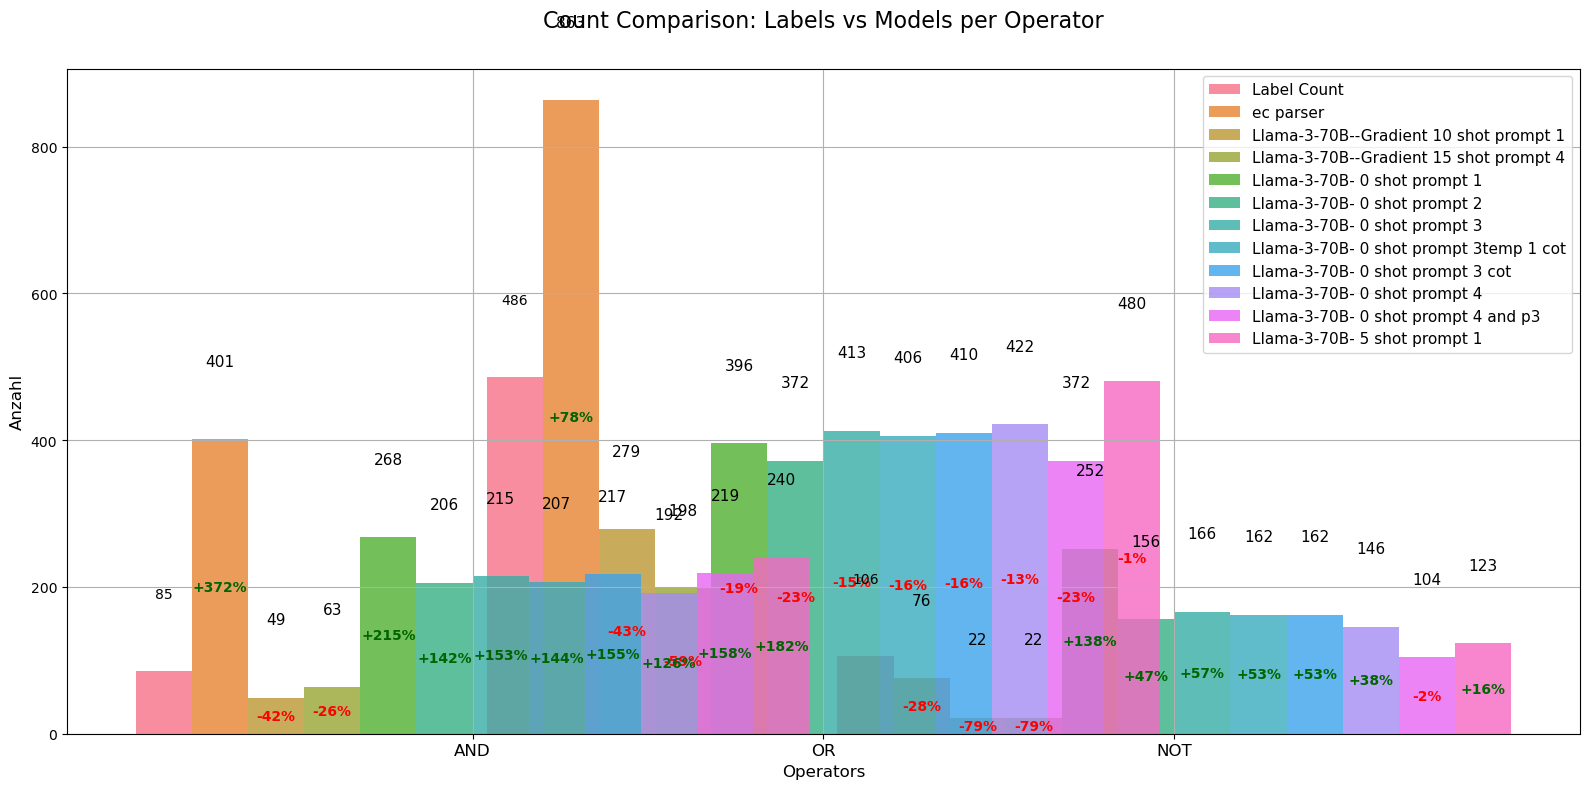

In [11]:
plot_count_comparison(all_metrics)

## Model vs SOTA


In [12]:
print(models)

model_to_plot = models[len(models)-1]
model_name = model_to_plot
model_to_plot

['ec_parser', 'Llama-3-70B-Instruct-Gradient_10_shot_prompt_1', 'Llama-3-70B-Instruct-Gradient_15_shot_prompt_4', 'Llama-3-70B-Instruct_0_shot_prompt_1', 'Llama-3-70B-Instruct_0_shot_prompt_2', 'Llama-3-70B-Instruct_0_shot_prompt_3', 'Llama-3-70B-Instruct_0_shot_prompt_3temp_1_cot', 'Llama-3-70B-Instruct_0_shot_prompt_3_cot', 'Llama-3-70B-Instruct_0_shot_prompt_4', 'Llama-3-70B-Instruct_0_shot_prompt_4_and_p3', 'Llama-3-70B-Instruct_5_shot_prompt_1']


'Llama-3-70B-Instruct_5_shot_prompt_1'

In [13]:
all_metrics

{'ec_parser': {'AND': {'precision': 17.33668341708543,
   'recall': 81.17647058823529,
   'f1': 28.571428571428577,
   'accuracy': 81.17647058823529,
   'total_label': 85,
   'total_model': 401,
   'correct_count': 69,
   'low_tp_ncts': []},
  'OR': {'precision': 48.481308411214954,
   'recall': 85.39094650205762,
   'f1': 61.847988077496275,
   'accuracy': 85.39094650205762,
   'total_label': 486,
   'total_model': 863,
   'correct_count': 415,
   'low_tp_ncts': []},
  'NOT': {'precision': 64.47368421052632,
   'recall': 46.22641509433962,
   'f1': 53.84615384615385,
   'accuracy': 46.22641509433962,
   'total_label': 106,
   'total_model': 76,
   'correct_count': 49,
   'low_tp_ncts': ['NCT03861819']},
  'average_missing_percentage': 1.0662774482481507,
  'average': {'precision': 43.4305586796089,
   'recall': 70.93127739487751,
   'f1': 48.088523498359564,
   'accuracy': 70.93127739487751}},
 'Llama-3-70B-Instruct-Gradient_10_shot_prompt_1': {'AND': {'precision': 40.816326530612244,

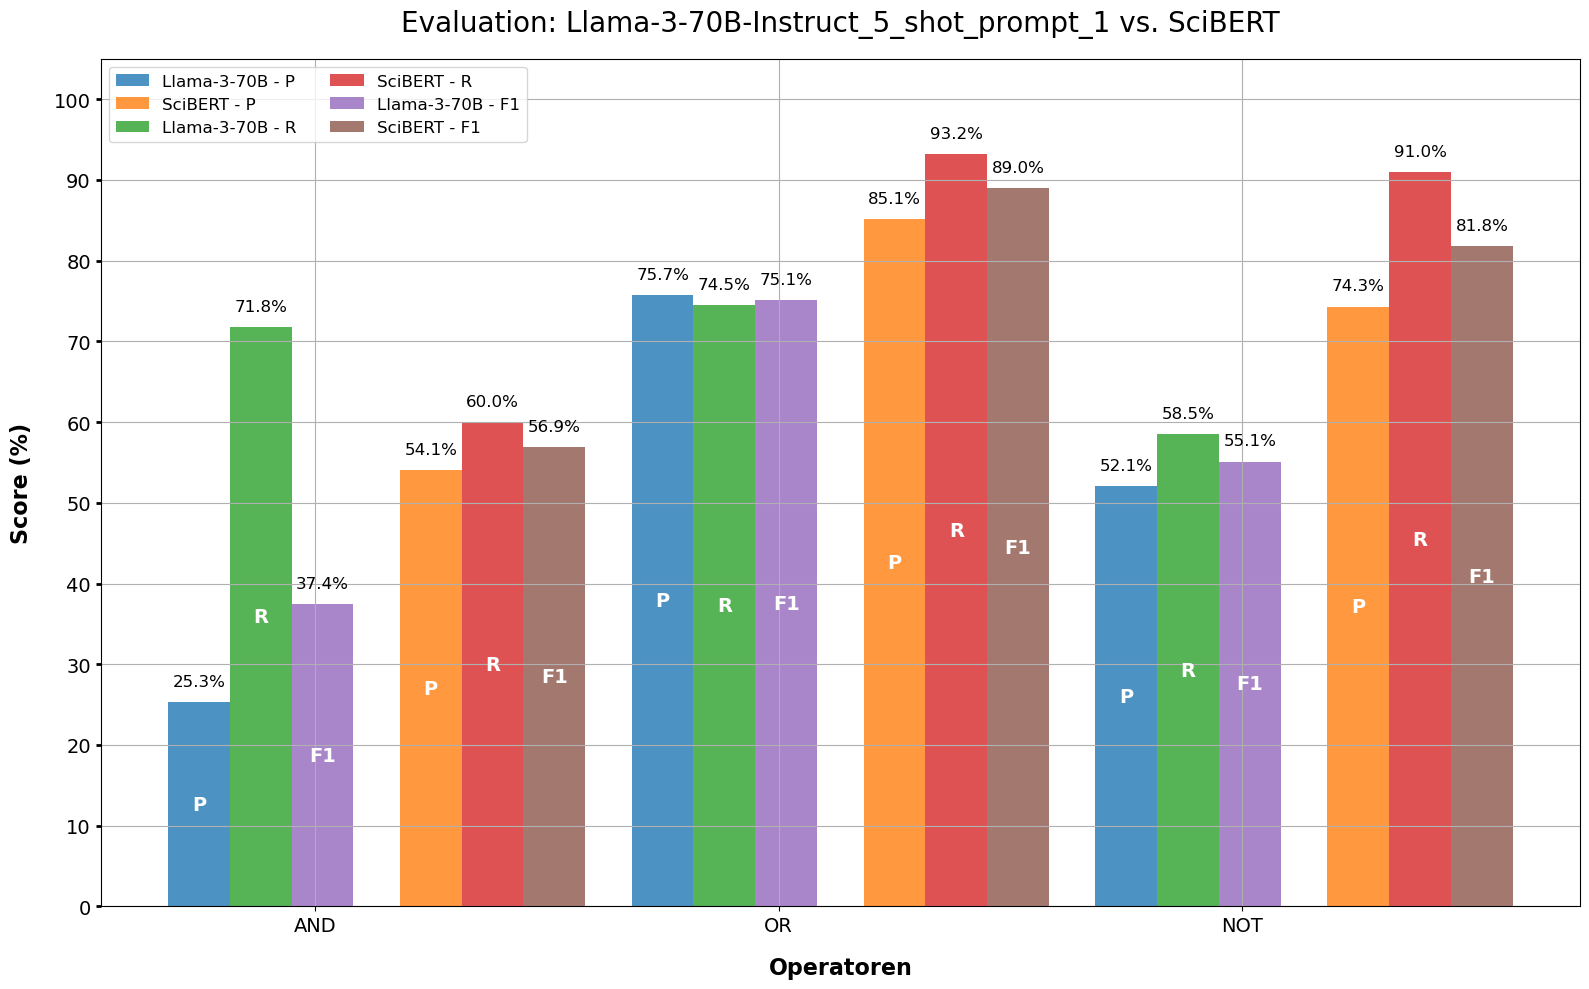

In [14]:
model_metrics = all_metrics[model_to_plot]


sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
    }
}

operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(operators))
bar_width = 0.4
opacity = 0.8
gap = 0.1

for i, metric in enumerate(metrics_to_plot):
    model_values = [model_metrics[op][metric] for op in operators]
    sota_values = [sota_metrics['SciBERT'][op][metric] for op in operators]

    ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
    ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

    for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(operators, fontsize=14)
ax.set_xlabel('Operatoren', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='y', labelsize=14, width=2)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
ax.legend(fontsize=12, ncol=2, loc='upper left')
ax.grid(True)

plt.tight_layout()
if not os.path.exists("pics"):
    os.makedirs("pics")
plt.savefig(f"pics/{model_to_plot}_vs_sota.png")
plt.show()

In [15]:
def generate_latex_table(all_metrics, operators, metrics_to_plot):
    latex_table = "\\begin{table}[h]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{l" + "c" * (len(metrics_to_plot) * len(operators)) + "}\n"
    latex_table += "\\toprule\n"
    latex_table += "Model & " + " & ".join([f"\\multicolumn{{{len(metrics_to_plot)}}}{{c}}{{{op}}}" for op in operators]) + " \\\\\n"
    latex_table += "\\cmidrule(lr){2-" + str(len(metrics_to_plot) + 1) + "} " + " \\cmidrule(lr){" + str(len(metrics_to_plot) + 2) + "-" + str(2 * len(metrics_to_plot) + 1) + "} " + " \\cmidrule(lr){" + str(2 * len(metrics_to_plot) + 2) + "-" + str(3 * len(metrics_to_plot) + 1) + "}\n"
    latex_table += " & " + " & ".join([" & ".join(metric[:1].upper() for metric in metrics_to_plot) for _ in operators]) + " \\\\\n"
    latex_table += "\\midrule\n"

    for model, model_metrics in all_metrics.items():
        row = model.replace("_", "-")  # Replace underscores with hyphens in the model name
        for op in operators:
            for metric in metrics_to_plot:
                row += " & {:.2f}".format(model_metrics[op][metric])
        row += " \\\\\n"
        latex_table += row

    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{Model Performance Metrics}\n"
    latex_table += "\\label{tab:model_metrics}\n"
    latex_table += "\\end{table}\n"

    os.makedirs("latex", exist_ok=True)
    with open("latex/model_metrics_table.tex", "w") as file:
        file.write(latex_table)
    return latex_table

# Generate LaTeX table
#latex_table = generate_latex_table(all_metrics, operators, metrics_to_plot)

#print(latex_table)

In [16]:
sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2}
    }
}

def calculate_average_metrics(metrics):
    avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0}
    operators = ['AND', 'NOT', 'OR']

    for metric in avg_metrics.keys():
        avg_metrics[metric] = sum(metrics[op][metric] for op in operators) / len(operators)

    return avg_metrics

for model, metrics in sota_metrics.items():
    avg_metrics = calculate_average_metrics(metrics)
    print(f"Average metrics for {model}: {avg_metrics}")

Average metrics for SciBERT: {'precision': 71.16666666666667, 'recall': 81.39999999999999, 'f1': 75.89999999999999}
Average metrics for R-BERT + SciBERT: {'precision': 72.23333333333333, 'recall': 78.23333333333333, 'f1': 75.0}
